<a href="https://colab.research.google.com/github/lithikaneelakandan56-ctrl/ml_practice/blob/main/ML/day06_decision_tree_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# using same data set but choosing decision tree
from sklearn.datasets import load_breast_cancer
import pandas as pd
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)
df = X.copy()
df["target"] = y
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [2]:
#data preprocessing
print("Missing values:", X.isnull().sum().sum())
print("Duplicate rows:", X.duplicated().sum())
print(y.value_counts())

Missing values: 0
Duplicate rows: 0
1    357
0    212
Name: count, dtype: int64


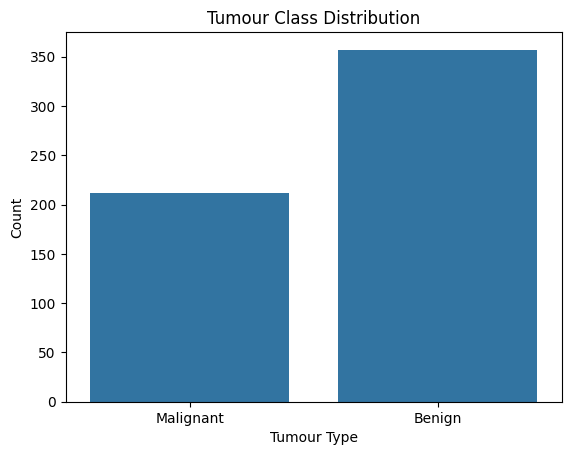

In [3]:
# eda of class distribution
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x=y.map({0: "Malignant", 1: "Benign"}))
plt.title("Tumour Class Distribution")
plt.xlabel("Tumour Type")
plt.ylabel("Count")
plt.show()

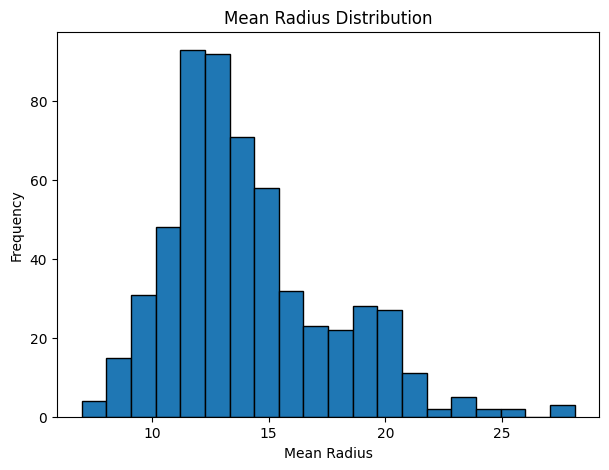

In [4]:
# eda of feature distribution
plt.figure(figsize=(7, 5))
plt.hist(X["mean radius"], bins=20, edgecolor="black")
plt.title("Mean Radius Distribution")
plt.xlabel("Mean Radius")
plt.ylabel("Frequency")
plt.show()

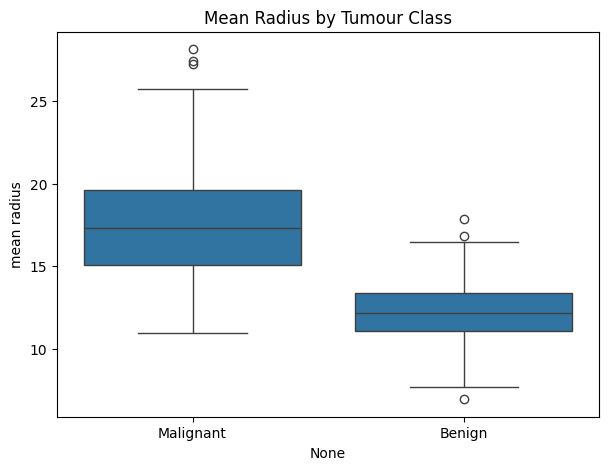

In [5]:
# feature comparison
plt.figure(figsize=(7, 5))
sns.boxplot(x=y.map({0: "Malignant", 1: "Benign"}),y=X["mean radius"])
plt.title("Mean Radius by Tumour Class")
plt.show()

In [7]:
# decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [8]:
#model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9473684210526315
Precision: 0.9577464788732394
Recall: 0.9577464788732394
F1 Score: 0.9577464788732394
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



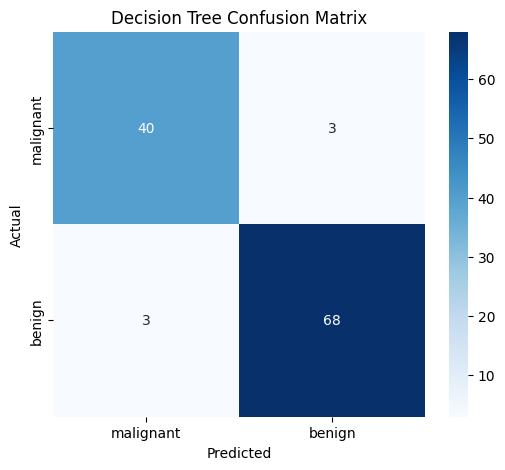

In [9]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [10]:
depths = [2, 4, 8]
for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    tree.fit(X_train, y_train)
    predictions = tree.predict(X_test)
    print("\nMax Depth:", depth)
    print("Accuracy:", accuracy_score(y_test, predictions))
    print("F1 Score:", f1_score(y_test, predictions))


Max Depth: 2
Accuracy: 0.9298245614035088
F1 Score: 0.9452054794520548

Max Depth: 4
Accuracy: 0.9473684210526315
F1 Score: 0.9577464788732394

Max Depth: 8
Accuracy: 0.9473684210526315
F1 Score: 0.9577464788732394


In [11]:
#Predict one test sample
sample = X_test.iloc[[0]]
prediction = model.predict(sample)
print("Predicted Class:", data.target_names[prediction[0]])
print("Actual Class:", data.target_names[y_test.iloc[0]])

Predicted Class: benign
Actual Class: benign


In [12]:
#Predict multiple samples
samples = X_test.iloc[:5]
predictions = model.predict(samples)
for i in range(len(predictions)):
    print("Sample", i + 1)
    print("Predicted:", data.target_names[predictions[i]])
    print("Actual:", data.target_names[y_test.iloc[i]])
    print("----------------------")

Sample 1
Predicted: benign
Actual: benign
----------------------
Sample 2
Predicted: malignant
Actual: malignant
----------------------
Sample 3
Predicted: malignant
Actual: malignant
----------------------
Sample 4
Predicted: benign
Actual: benign
----------------------
Sample 5
Predicted: benign
Actual: benign
----------------------


In [13]:
probabilities = model.predict_proba(sample)
print("Malignant Probability:", probabilities[0][0])
print("Benign Probability:", probabilities[0][1])

Malignant Probability: 0.007722007722007722
Benign Probability: 0.9922779922779923


In [14]:
# user input prediction
import pandas as pd
# Get input from the user
print("Enter the following tumour details:")
mean_radius = float(input("Mean Radius: "))
mean_texture = float(input("Mean Texture: "))
mean_perimeter = float(input("Mean Perimeter: "))
mean_area = float(input("Mean Area: "))
mean_smoothness = float(input("Mean Smoothness: "))
# Create input using the selected features
user_input = pd.DataFrame([{
    "mean radius": mean_radius,
    "mean texture": mean_texture,
    "mean perimeter": mean_perimeter,
    "mean area": mean_area,
    "mean smoothness": mean_smoothness
}])
# Add remaining features with placeholder values
for column in X.columns:
    if column not in user_input.columns:
        user_input[column] = X[column].median()
# Keep the same feature order used during training
user_input = user_input[X.columns]
# Predict
prediction = model.predict(user_input)
print("\nPredicted Tumour Type:",
      data.target_names[prediction[0]])

Enter the following tumour details:
Mean Radius: 56
Mean Texture: 43
Mean Perimeter: 23
Mean Area: 12
Mean Smoothness: 23

Predicted Tumour Type: benign
